# Spotify Data EDA

This notebook provides an in-depth exploratory data analysis (EDA) of the `spotify_data.parquet` dataset, including a variety of visualizations to uncover trends, patterns, and insights.

## 1. Import Required Libraries
We use polars for fast data loading, pandas for compatibility, and matplotlib, seaborn, and plotly for visualization.

In [3]:
# Core libraries
import polars as pl
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Misc
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Load the Dataset
We load the dataset using polars for speed, then convert to pandas for compatibility with most visualization libraries.

In [4]:
# Load the dataset with polars for speed
pl_df = pl.read_parquet('spotify_5000.parquet')
df = pl_df.to_pandas()
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns.")
df.head()

Loaded 5,000 rows and 21 columns.


,track_id,original_name,original_artist,id,name,title,uri,type,duration,duration_ms,...,preview_url,is_explicit,is_playable,album,release_date,metadata_status,lyrics,lyrics_status,stream_count,popularity
0,0yLdNVWF3Srea0uzk55zFn,Flowers,Miley Cyrus,0yLdNVWF3Srea0uzk55zFn,Flowers,Flowers,spotify:track:0yLdNVWF3Srea0uzk55zFn,track,200454.0,200454.0,...,https://p.scdn.co/mp3-preview/698a0cb24c583903...,False,True,"{'images': [{'height': 300, 'url': 'https://im...",2023-01-13,ok,"We were good, we were gold\nKinda dream that c...",ok_lrclib,2.809638e+09,100
1,4nrPB8O7Y7wsOCJdgXkthe,"Shakira: Bzrp Music Sessions, Vol. 53",Bizarrap,4nrPB8O7Y7wsOCJdgXkthe,"Shakira: Bzrp Music Sessions, Vol. 53/66","Shakira: Bzrp Music Sessions, Vol. 53/66",spotify:track:4nrPB8O7Y7wsOCJdgXkthe,track,214945.0,214945.0,...,https://p.scdn.co/mp3-preview/95e346339b509205...,False,True,"{'images': [{'height': 300, 'url': 'https://im...",2023-01-11,ok,Pa tipos como tú-ú-ú-ú-ú\nOh-oh (oh-oh)\nPa ti...,ok_lrclib,1.153606e+09,96
2,7oDd86yk8itslrA9HRP2ki,Die For You - Remix,The Weeknd,7oDd86yk8itslrA9HRP2ki,Die For You - Remix,Die For You - Remix,spotify:track:7oDd86yk8itslrA9HRP2ki,track,232857.0,232857.0,...,https://p.scdn.co/mp3-preview/82b56807037e361f...,False,True,"{'images': [{'height': 300, 'url': 'https://im...",2023-02-24,ok,I'm findin' ways to articulate the feelin' I'm...,ok_lrclib,3.189438e+09,95
3,1Qrg8KqiBpW07V7PNxwwwL,Kill Bill,SZA,1Qrg8KqiBpW07V7PNxwwwL,Kill Bill,Kill Bill,spotify:track:1Qrg8KqiBpW07V7PNxwwwL,track,153946.0,153946.0,...,https://p.scdn.co/mp3-preview/f29963023285c89b...,False,True,"{'images': [{'height': 300, 'url': 'https://im...",2022-12-08,ok,"I'm still a fan, even though I was salty\nHate...",ok_lrclib,2.747259e+09,94
4,5ww2BF9slyYgNOk37BlC4u,La Bachata,Manuel Turizo,5ww2BF9slyYgNOk37BlC4u,La Bachata,La Bachata,spotify:track:5ww2BF9slyYgNOk37BlC4u,track,162637.0,162637.0,...,https://p.scdn.co/mp3-preview/8823eac6ff69e534...,False,True,"{'images': [{'height': 300, 'url': 'https://im...",2022-05-26,ok,"Te bloqueé de Insta, pero por otra cuenta veo ...",ok_lrclib,2.374237e+09,93


## 3. Inspect Dataset Structure
Preview the dataset, check its shape, column names, and data types.

In [5]:
# Shape, columns, and dtypes
print(f"Shape: {df.shape}")
df.info()
df.columns.tolist()

Shape: (5000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   track_id         5000 non-null   object 
 1   original_name    5000 non-null   object 
 2   original_artist  5000 non-null   object 
 3   id               5000 non-null   object 
 4   name             5000 non-null   object 
 5   title            5000 non-null   object 
 6   uri              5000 non-null   object 
 7   type             5000 non-null   object 
 8   duration         5000 non-null   float64
 9   duration_ms      5000 non-null   float64
 10  artists          5000 non-null   object 
 11  preview_url      4988 non-null   object 
 12  is_explicit      5000 non-null   bool   
 13  is_playable      5000 non-null   bool   
 14  album            4999 non-null   object 
 15  release_date     4999 non-null   object 
 16  metadata_status  5000 non-null   object 
 

['track_id',
 'original_name',
 'original_artist',
 'id',
 'name',
 'title',
 'uri',
 'type',
 'duration',
 'duration_ms',
 'artists',
 'preview_url',
 'is_explicit',
 'is_playable',
 'album',
 'release_date',
 'metadata_status',
 'lyrics',
 'lyrics_status',
 'stream_count',
 'popularity']

## 4. Summary Statistics
Generate descriptive statistics for numeric and categorical columns.

In [6]:
# Numeric features
df.describe().T

# Categorical features
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df[cat_cols].describe().T

,count,unique,top,freq
track_id,5000,5000,0yLdNVWF3Srea0uzk55zFn,1
original_name,5000,4847,Forever,4
original_artist,5000,1678,Taylor Swift,99
id,5000,5000,0yLdNVWF3Srea0uzk55zFn,1
name,5000,4844,Forever,4
title,5000,4844,Forever,4
uri,5000,5000,spotify:track:0yLdNVWF3Srea0uzk55zFn,1
type,5000,1,track,5000
artists,5000,2905,"[{'id': '06HL4z0CvFAxyc27GXpf02', 'name': 'Tay...",89
preview_url,4988,4980,https://p.scdn.co/mp3-preview/111eb776b2884b29...,2


## 5. Missing Values Analysis
Visualize and quantify missing values using bar plots and a heatmap.

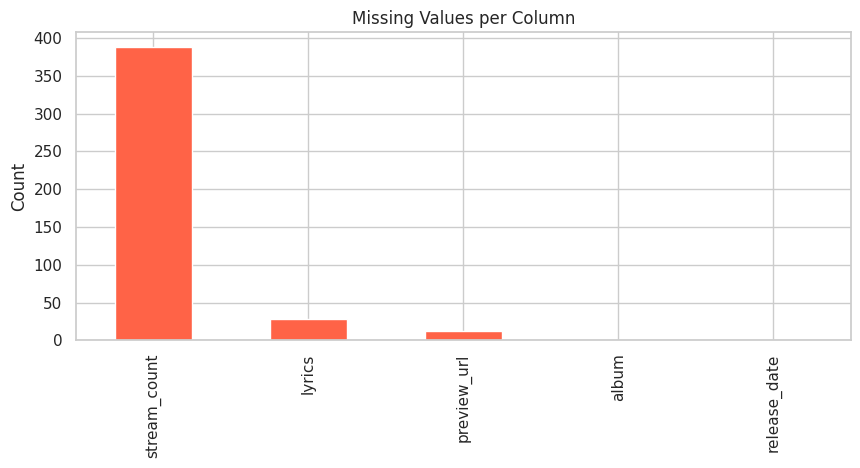

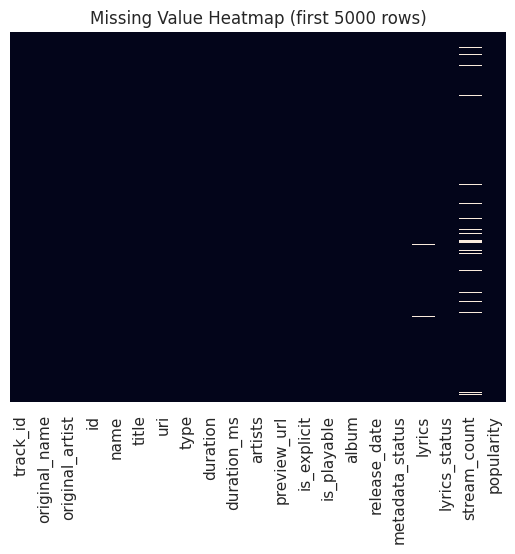

In [7]:
# Bar plot of missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
plt.figure(figsize=(10,4))
missing.plot(kind='bar', color='tomato')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.show()

# Heatmap of missing values (first 5000 rows for speed)
sns.heatmap(df.isnull().iloc[:5000], cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (first 5000 rows)')
plt.show()

## 6. Distribution of Numeric Features
Visualize the distributions of key numeric features using histograms and boxplots.

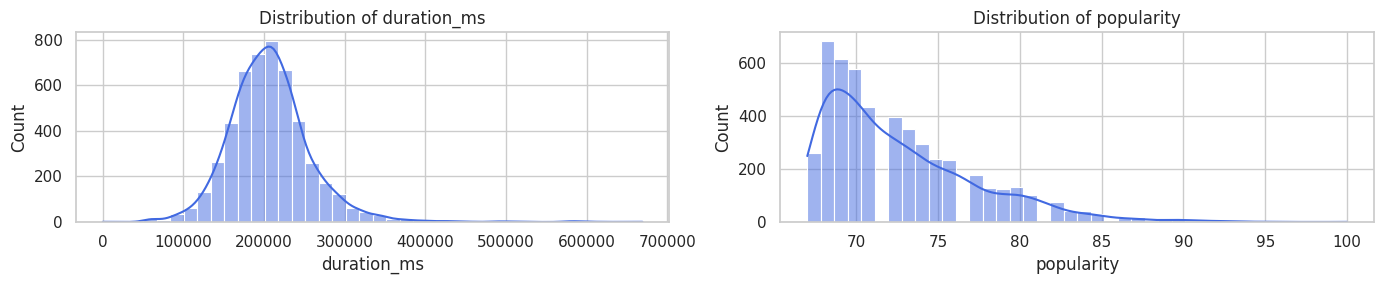

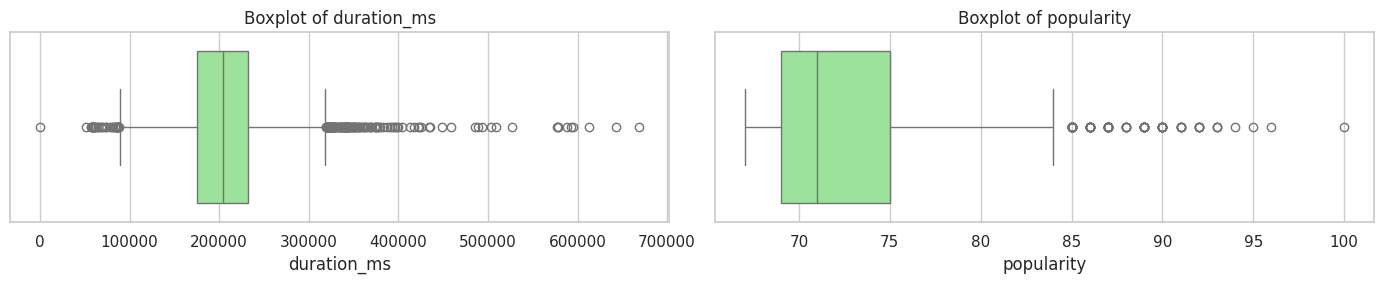

In [8]:
num_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity'
]
num_cols = [c for c in num_cols if c in df.columns]

# Histograms
n = len(num_cols)
ncols = 2
nrows = (n + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i], kde=True, color='royalblue')
    axes[i].set_title(f"Distribution of {col}")
# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f"Boxplot of {col}")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap
Visualize the correlation matrix for numeric features.

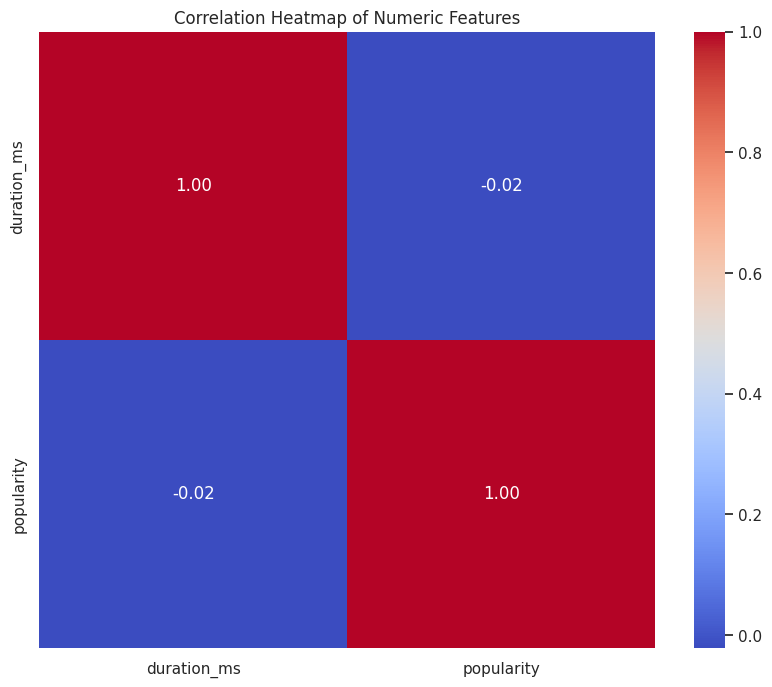

In [9]:
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## 8. Top Artists and Tracks
Visualize the most frequent artists and tracks.

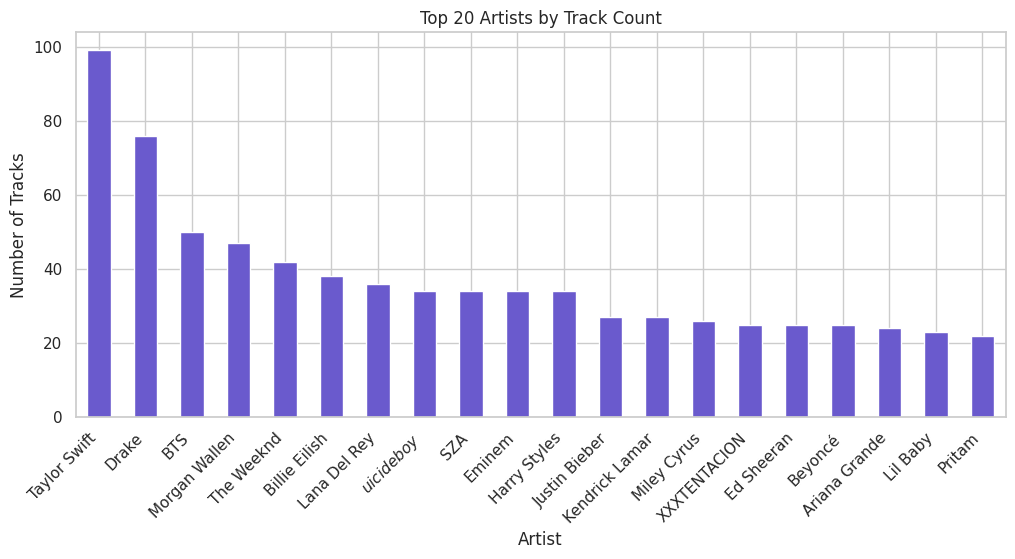

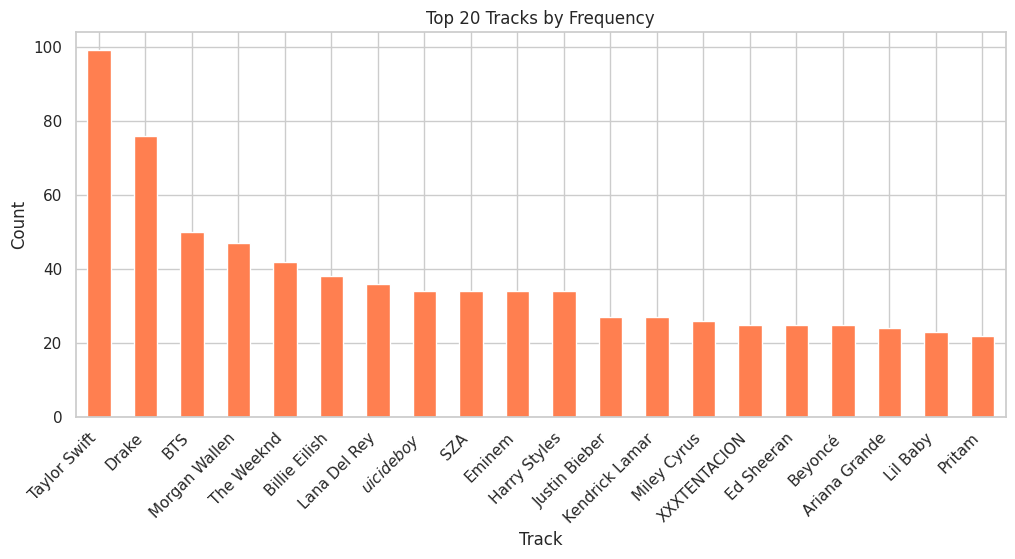

In [ ]:
# Top 20 artists by track count
plt.figure(figsize=(12,5))
df['original_artist'].value_counts().head(20).plot(kind='bar', color='slateblue')
plt.title('Top 20 Artists by Track Count')
plt.ylabel('Number of Tracks')
plt.xlabel('Artist')
plt.xticks(rotation=45, ha='right')
plt.show()

# Top 20 tracks by frequency
plt.figure(figsize=(12,5))
df['original_artist'].value_counts().head(20).plot(kind='bar', color='coral')
plt.title('Top 20 Tracks by Frequency')
plt.ylabel('Count')
plt.xlabel('Track')
plt.xticks(rotation=45, ha='right')
plt.show()

## 9. Genre Popularity Analysis
Analyze and visualize the distribution and popularity of different genres.

In [12]:
# Top genres by track count
genre_counts = df['genre'].value_counts().head(20)
plt.figure(figsize=(12,5))
genre_counts.plot(kind='bar', color='mediumseagreen')
plt.title('Top 20 Genres by Track Count')
plt.ylabel('Number of Tracks')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.show()

# Average popularity by genre
genre_pop = df.groupby('genre')['popularity'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,5))
genre_pop.plot(kind='bar', color='goldenrod')
plt.title('Top 20 Genres by Average Popularity')
plt.ylabel('Average Popularity')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.show()

KeyError: 'genre'

## 10. Audio Feature Relationships
Explore relationships between audio features using pairplots and scatter plots.

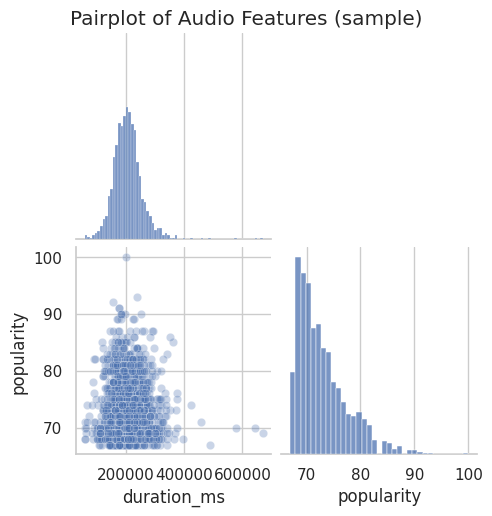

ValueError: Could not interpret value `danceability` for `x`. An entry with this name does not appear in `data`.

<Figure size 700x500 with 0 Axes>

In [13]:
# Pairplot of selected features (sampled for speed)
sample_df = df[num_cols].dropna().sample(n=2000, random_state=42) if len(df) > 2000 else df[num_cols].dropna()
sns.pairplot(sample_df, corner=True, plot_kws={'alpha':0.3})
plt.suptitle('Pairplot of Audio Features (sample)', y=1.02)
plt.show()

# Scatter: danceability vs. energy
plt.figure(figsize=(7,5))
sns.scatterplot(x='danceability', y='energy', data=sample_df, alpha=0.4)
plt.title('Danceability vs. Energy')
plt.show()

## 11. Temporal Trends in Song Releases
Visualize the number of songs released per year and trends over time.

In [14]:
# Number of songs released per year
year_counts = df['year'].value_counts().sort_index()
plt.figure(figsize=(12,5))
year_counts.plot(kind='bar', color='orchid')
plt.title('Number of Songs Released per Year')
plt.ylabel('Number of Songs')
plt.xlabel('Year')
plt.show()

# Trend: average popularity by year
if 'popularity' in df.columns:
    avg_pop_by_year = df.groupby('year')['popularity'].mean()
    plt.figure(figsize=(12,5))
    avg_pop_by_year.plot(marker='o', color='teal')
    plt.title('Average Popularity by Year')
    plt.ylabel('Average Popularity')
    plt.xlabel('Year')
    plt.show()

KeyError: 'year'

## 12. Popularity vs. Audio Features
Plot relationships between song popularity and selected audio features.

In [16]:
# Popularity vs. danceability
plt.figure(figsize=(7,5))
sns.scatterplot(x='danceability', y='popularity', data=sample_df, alpha=0.3)
plt.title('Popularity vs. Danceability')
plt.show()

# Popularity vs. energy
plt.figure(figsize=(7,5))
sns.scatterplot(x='energy', y='popularity', data=sample_df, alpha=0.3)
plt.title('Popularity vs. Energy')
plt.show()

# Popularity vs. valence
plt.figure(figsize=(7,5))
sns.scatterplot(x='valence', y='popularity', data=sample_df, alpha=0.3)
plt.title('Popularity vs. Valence')
plt.show()

ValueError: Could not interpret value `danceability` for `x`. An entry with this name does not appear in `data`.

<Figure size 700x500 with 0 Axes>

## 13. Custom Visualizations
Additional visualizations to explore interesting patterns or answer user-driven questions.

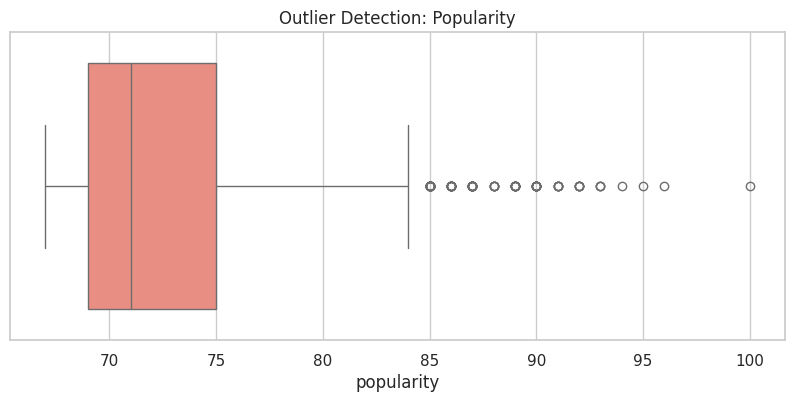

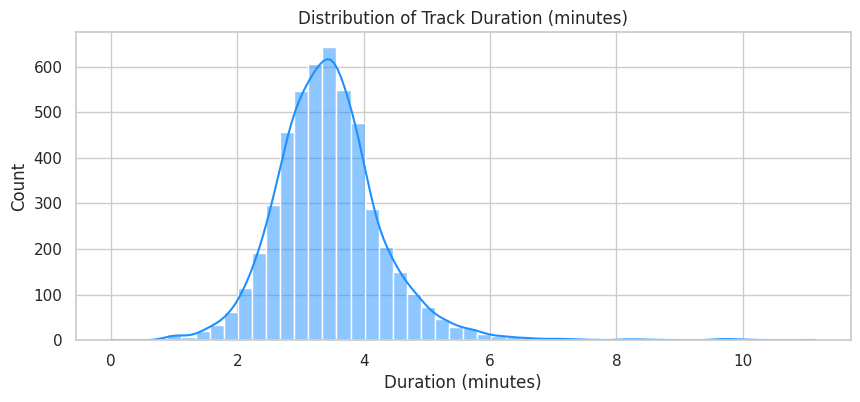

KeyError: "['track_name', 'artist_name', 'genre', 'year'] not in index"

In [17]:
# Outlier detection: popularity
plt.figure(figsize=(10,4))
sns.boxplot(x=df['popularity'], color='salmon')
plt.title('Outlier Detection: Popularity')
plt.show()

# Distribution of track duration (in minutes)
df['duration_min'] = df['duration_ms'] / 60000
plt.figure(figsize=(10,4))
sns.histplot(df['duration_min'], bins=50, color='dodgerblue', kde=True)
plt.title('Distribution of Track Duration (minutes)')
plt.xlabel('Duration (minutes)')
plt.show()

# Top 10 most popular tracks
if 'popularity' in df.columns:
    top_tracks = df.sort_values('popularity', ascending=False).drop_duplicates('track_id').head(10)
    display(top_tracks[['track_name', 'artist_name', 'popularity', 'genre', 'year']])